# Task 2: Empirical Diagnostic of Custom Weight Initializations and Gradient Vanishing

**Objective:** Analyze mathematical training instability in deep neural networks by tracking activation distributions and gradient magnitudes under varying initialization distributions.

### Weight Initializations
1. **Random Normal Initialization:**
   $$W \sim \mathcal{N}(0, \sigma^2)$$
2. **Xavier (Glorot) Normal Initialization:**
   $$W \sim \mathcal{N}\left(0, \frac{2}{n_{in} + n_{out}}\right)$$
3. **Kaiming (He) Normal Initialization:**
   $$W \sim \mathcal{N}\left(0, \frac{2}{n_{in}}\right)$$

In [4]:
import torch
import numpy as np
import matplotlib.pyplot as plt

# Disable gradient computation globally to ensure manual tracking
torch.set_grad_enabled(False)

# Custom initialization routines
def random_normal_init(shape, std=1.0):
    return torch.randn(shape) * std

def xavier_normal_init(shape):
    n_in, n_out = shape[0], shape[1]
    std = np.sqrt(2.0 / (n_in + n_out))
    return torch.randn(shape) * std

def kaiming_normal_init(shape):
    n_in = shape[0]
    std = np.sqrt(2.0 / n_in)
    return torch.randn(shape) * std

class CustomLinearModule:
    def __init__(self, input_dim, output_dim, init_fn):
        self.W = init_fn((input_dim, output_dim))
        self.b = torch.zeros(output_dim)
        self.X_cache = None
        self.Z_cache = None
        self.dW = None
        
    def forward(self, X):
        self.X_cache = X
        self.Z_cache = torch.matmul(X, self.W) + self.b
        return torch.relu(self.Z_cache)
        
    def backward(self, dAct):
        # Local gradient: relu derivative
        dZ = dAct * (self.Z_cache > 0).float()
        # Parameters gradient estimation
        self.dW = torch.matmul(self.X_cache.t(), dZ) / self.X_cache.shape[0]
        # Return gradient to pass backward
        dAct_prev = torch.matmul(dZ, self.W.t())
        return dAct_prev

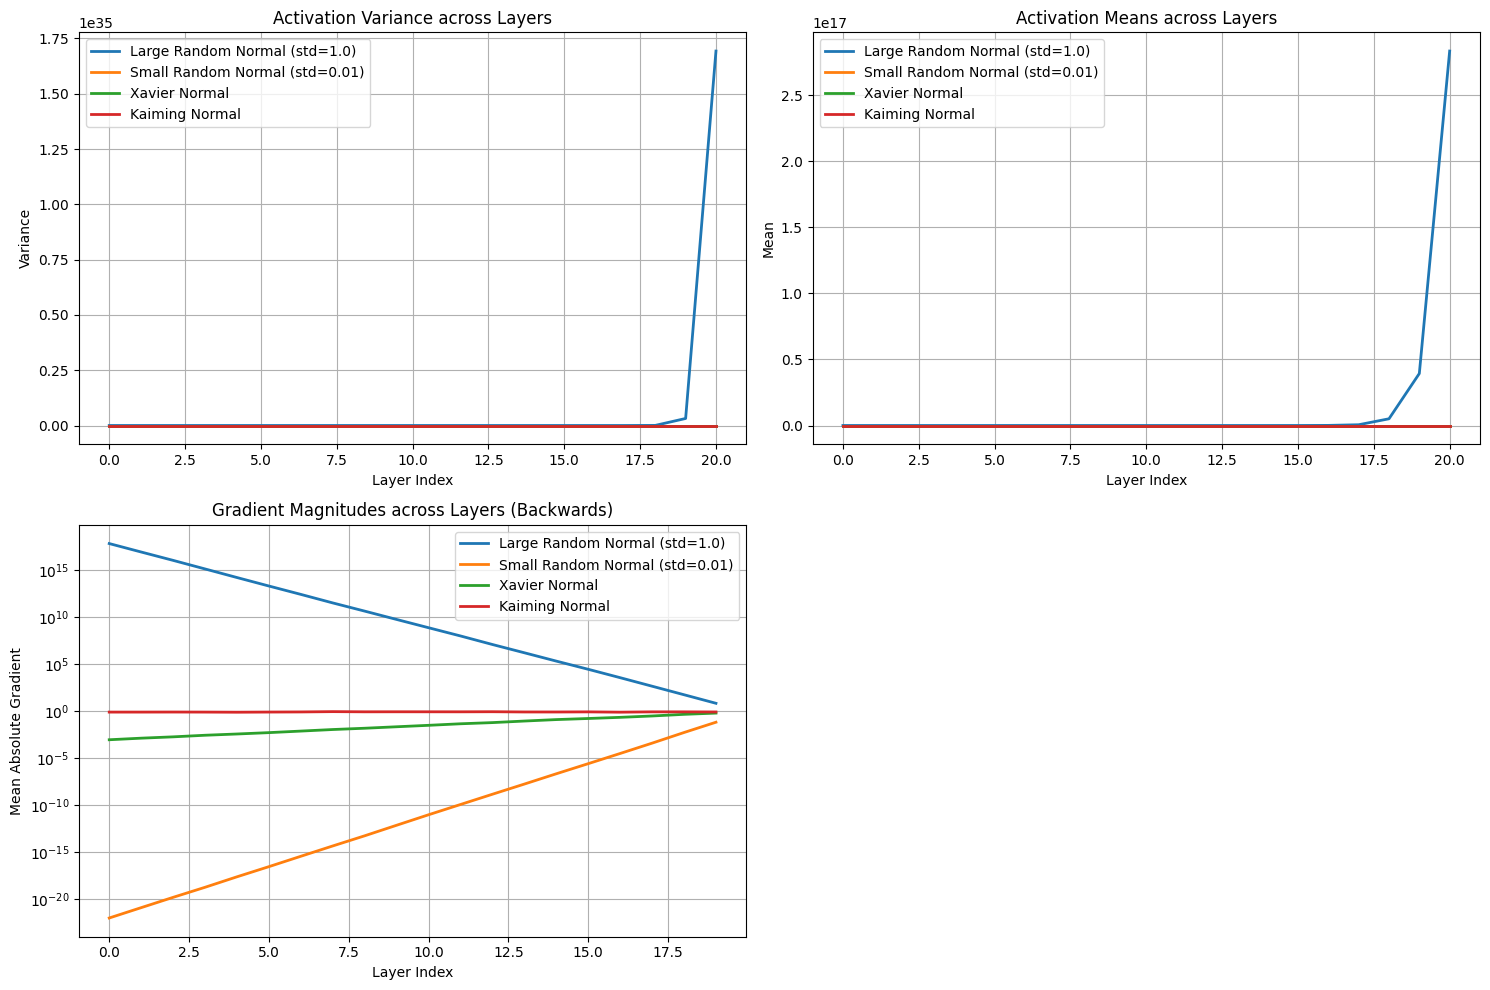

In [5]:
# Setup a 20-Layer deep network with custom tracking
layer_dim = 128
num_layers = 20
batch_size = 64
X_input = torch.randn(batch_size, layer_dim)

initializations = {
    "Large Random Normal (std=1.0)": lambda shape: random_normal_init(shape, std=1.0),
    "Small Random Normal (std=0.01)": lambda shape: random_normal_init(shape, std=0.01),
    "Xavier Normal": xavier_normal_init,
    "Kaiming Normal": kaiming_normal_init
}

results = {}

for init_name, init_fn in initializations.items():
    # Instantiate layers
    layers = [CustomLinearModule(layer_dim, layer_dim, init_fn) for _ in range(num_layers)]
    
    # Forward pass tracking activation statistics
    activations = [X_input]
    current_act = X_input
    for layer in layers:
        current_act = layer.forward(current_act)
        activations.append(current_act)
        
    # Setup mock output gradient for manual backward
    dAct = torch.randn(batch_size, layer_dim)
    grad_magnitudes = []
    
    # Backward pass tracking gradient magnitudes
    for layer in reversed(layers):
        dAct = layer.backward(dAct)
        grad_magnitudes.append(torch.mean(torch.abs(dAct)).item())
        
    # Store statistics
    results[init_name] = {
        "activation_means": [torch.mean(act).item() for act in activations],
        "activation_vars": [torch.var(act).item() for act in activations],
        "grad_mags": list(reversed(grad_magnitudes))
    }

# Plotting Statistics
plt.figure(figsize=(15, 10))

# Activation Variance vs Layer
plt.subplot(2, 2, 1)
for init_name, stats in results.items():
    plt.plot(stats["activation_vars"], label=init_name, lw=2)
plt.title("Activation Variance across Layers")
plt.xlabel("Layer Index")
plt.ylabel("Variance")
plt.grid(True)
plt.legend()

# Activation Means vs Layer
plt.subplot(2, 2, 2)
for init_name, stats in results.items():
    plt.plot(stats["activation_means"], label=init_name, lw=2)
plt.title("Activation Means across Layers")
plt.xlabel("Layer Index")
plt.ylabel("Mean")
plt.grid(True)
plt.legend()

# Gradient Magnitudes vs Layer
plt.subplot(2, 2, 3)
for init_name, stats in results.items():
    plt.plot(stats["grad_mags"], label=init_name, lw=2)
plt.title("Gradient Magnitudes across Layers (Backwards)")
plt.xlabel("Layer Index")
plt.ylabel("Mean Absolute Gradient")
plt.yscale('log')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()